In [150]:
# %pip install pyDOE

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [13]:
import sys
# sys.path.insert(0, '/content/drive/MyDrive/burgers_shock_mu_01_pi.mats') #upload utilities folder to your google drive before running the lines

In [14]:
# adam optimizer. 0.093 for nu in the last run
# added validation loss 
# should I expect my NN weights to converge?
# check the seeds
# continue training until the val loss goes higer than training loss
# check if the derivation is correct.
# add regularization: l1, l2, dropout
import tensorflow as tf
import datetime, os
#hide tf logs 
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # or any {'0', '1', '2'} 
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
#0 (default) shows all, 1 to filter out INFO logs, 2 to additionally filter out WARNING logs, and 3 to additionally filter out ERROR logs
import scipy.optimize
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import time
from pyDOE import lhs       #Latin Hypercube Sampling
# import lhs

# specify random seeds for reproducible results
np.random.seed(2)
tf.random.set_seed(2)

In [15]:
# data = scipy.io.loadmat('../content/drive/MyDrive/burgers_shock.mat')  	# Load data
# data = scipy.io.loadmat('../content/drive/MyDrive/burgers_shock_mu_01_pi.mat')  	# Load data
# data = scipy.io.loadmat('../content/drive/MyDrive/burgers_shock_mu_005_pi.mat')
data = scipy.io.loadmat('./data/burgers_shock_mu_005_pi.mat')  	# Load data
x = data['x']                                   # 256 points between -1 and 1 [256x1]
t = data['t']                                   # 100 time points between 0 and 1 [100x1] 
usol = data['usol']                             # solution of 256x100 grid points used only for testing (not for training)
X, T = np.meshgrid(x,t) 

In [16]:
X_u_test = np.hstack((X.flatten()[:,None], T.flatten()[:,None]))

# Domain bounds
lb = X_u_test[0]  # [-1. 0.]
ub = X_u_test[-1] # [1.  0.99]

'''
   Fortran Style ('F') flatten,stacked column wise!
   u = [c1 
        c2
        .
        .
        cn]

   u =  [25600x1] 
'''
u = usol.flatten('F')[:,None] # fortran style was used to make solution points compatible with (x,t) coordinate points

In [17]:
def trainingdata(N_u, N_f): ### randomize the choice on baoundary points

    '''Boundary Conditions'''

    #Initial Condition -1 =< x =<1 and t = 0  
    leftedge_x = np.hstack((X[0,:][:,None], T[0,:][:,None])) #L1
    leftedge_u = usol[:,0][:,None]

    #Boundary Condition x = -1 and 0 =< t =<1
    bottomedge_x = np.hstack((X[:,0][:,None], T[:,0][:,None])) #L2
    bottomedge_u = usol[-1,:][:,None]

    #Boundary Condition x = 1 and 0 =< t =<1
    topedge_x = np.hstack((X[:,-1][:,None], T[:,0][:,None])) #L3
    topedge_u = usol[0,:][:,None]

    all_X_u_train = np.vstack([leftedge_x, bottomedge_x, topedge_x]) # X_u_train [456,2] (456 = 256(L1)+100(L2)+100(L3))
    all_u_train = np.vstack([leftedge_u, bottomedge_u, topedge_u])   #corresponding u [456x1]

    #choose random N_u points for training
    idx = np.random.choice(all_X_u_train.shape[0], N_u, replace=False) 

    X_u_train_rand = all_X_u_train[idx, :] #choose indices from  set 'idx' (x,t) #### randomize boundary point selection like in
    #### collocation points
    u_train_rand = all_u_train[idx,:]      #choose corresponding u

    '''Collocation Points'''

    # Latin Hypercube sampling for collocation points 
    # N_f sets of tuples(x,t)
    X_f_train = lb + (ub-lb)*lhs(2,N_f)
#     print(X_f_train.shape)
    X_f_train = np.vstack((X_f_train, X_u_train_rand)) # append training points to collocation points 

    return X_f_train, X_u_train_rand, u_train_rand 

def validationdata(N_u, N_f):

    #Initial Condition -1 =< x =<1 and t = 0  
    leftedge_x = np.hstack((X[0,:][:,None], T[0,:][:,None])) #L1
    leftedge_u = usol[:,0][:,None]

    #Boundary Condition x = -1 and 0 =< t =<1
    bottomedge_x = np.hstack((X[:,0][:,None], T[:,0][:,None])) #L2
    bottomedge_u = usol[-1,:][:,None]

    #Boundary Condition x = 1 and 0 =< t =<1
    topedge_x = np.hstack((X[:,-1][:,None], T[:,0][:,None])) #L3
    topedge_u = usol[0,:][:,None]

    all_X_u = np.vstack([leftedge_x, bottomedge_x, topedge_x]) # X_u [456,2] (456 = 256(L1)+100(L2)+100(L3))
    all_u = np.vstack([leftedge_u, bottomedge_u, topedge_u])   #corresponding u [456x1]

    #choose random N_u points for training
    idx = np.random.choice(all_X_u.shape[0], N_u, replace=False) #### the validation idx set has some mutual elements with the training idx set. make it exclusive.

    X_u_val_rand = all_X_u[idx, :] #choose indices from  set 'idx' (x,t) #### randomize boundary point selection like in
    #### collocation points
    u_val_rand = all_u[idx,:]      #choose corresponding u

    X_f_val = lb + (ub-lb)*lhs(2,N_f)

    X_f_val = np.vstack((X_f_val, X_u_val_rand)) # X_f_val includes the (x,t) coordinates of all the data. i.e. a small random set of boundary points plus a large set of collocation points. 

    return X_f_val, X_u_val_rand, u_val_rand 



In [18]:
class PINN(tf.Module): 
    def __init__(self, name=None):
        super().__init__(name = name)
        self.loss_history = np.array([])
        self.loss_val_history = np.array([])
        self.nu_history = np.array([])
        self.w_history = np.array([])
        self.nu = tf.Variable(0.003, dtype='float64', trainable = True)
        self.num_inter = 0
    
    def NN(self, layers): ### if you need to get the weights from user, pass it to the
        ### pass it to the function. otherwise, do not pass the weights.
        ### for now set length of layers an even number.
        self.layers = layers
        self.W = []
        for i in range(len(layers)): ### enumerate
            if i==len(layers)-1: break
            w = tf.random.normal([layers[i], layers[i+1]], dtype = 'float64')
            w = tf.Variable(w, trainable = True)
            b = tf.zeros([1, layers[i+1]], dtype='float64', name=None) ### no bias for last output
            b = tf.Variable(b, trainable = True)
### edit tf.zeros for flexibility with other layer types
            self.W.append(w)
            self.W.append(b)
#         return W ### is return really necessary?
    
    def forward(self, inpu): ### do not specify input type
#         pass 
### try adding a normalization function 
        self.inpu = inpu
#         print('inpu.shape:', inpu.shape)
        inner = inpu
        for i, layer in enumerate(self.W):
            if i==len(self.W)/2 : break ### half of the length of layers ## lenth of W is always even so we don't care
                ## about the remnant of the devision.
#             print(i)
            inner = tf.matmul(inner, self.W[2*i])
            inner = tf.add(inner, self.W[2*i+1]) ### add activation function, now it's unit activation
            if i==len(self.W)/2-1: break # no activation for last layer
#         inner = tf.nn.tanh(inner) # bug: do not specify union function as activation coz the second derivative is zero
        # however, gradient tape returns none type and returns incompatibility type error for the rest of calculations
#         inner = tf.nn.relu(inner)
            inner = tf.math.sigmoid(inner)
        outpu = inner
        return outpu
        
    def PDE(self, X_f): 
#         self.nu = tf.Variable(0.003, dtype='float64', trainable = True)
        xt_var = tf.Variable(X_f, dtype='float64', trainable = False)
#         xt_var = tf.Variable(X_f, dtype='float64', trainable = False) ### try other dtypes here and in general
        ### check it it should be trainable
        # we meade a variable coz tape.gradient only takes the derivation of input with respect to a variable
        x_var = xt_var[:,0:1]
        t_var = xt_var[:,1:2]
#         print(x_var)
#         print(t_var)
        with tf.GradientTape(persistent = True) as tape1:
            tape1.watch(x_var)
            tape1.watch(t_var)
            with tf.GradientTape(persistent = True) as tape2:
                tape2.watch(x_var)
                tape2.watch(t_var)
                proxy_xt = tf.stack([x_var[:,0], t_var[:,0]], axis=1)
                u_pred = self.forward(proxy_xt)
            u_pred_x = tape2.gradient(u_pred, x_var) # gradient of u_pred with respect to x_var
        u_pred_t = tape2.gradient(u_pred, t_var) # gradient of u_pred with respect to x_var 
        u_pred_xt = tape1.gradient(u_pred_x, t_var) # gradient of u_pred_x with respect to t_var
        u_pred_xx = tape1.gradient(u_pred_x, x_var) # gradient of u_pred_x with respect to x_var
        del tape1
        del tape2
        
        f = u_pred_t + u_pred*u_pred_x - self.nu*u_pred_xx
#         print(u_pred_xx.shape)
        
        return f

    def loss(self, X_f, X_u, u):
        X_u = tf.Variable(X_u, dtype='float64', trainable = False)
        u = tf.Variable(u, dtype='float64', trainable = False)
        e_DD = self.forward(X_u) - u
        loss_DD = tf.reduce_mean(tf.square(e_DD))
        
        f = self.PDE(X_f)
        loss_PI = tf.reduce_mean(tf.square(f)) # physics-informed loss

        # loss_w_l2 = tf.reduce_mean(tf.square(self.get_weights()))
        # loss_w_l1 = tf.reduce_mean(tf.abs(self.get_weights()))

        # loss = 0.5 * loss_PI + 0.5 * loss_DD ### try different weights
        loss = 0.5 * loss_PI + 0.5 * loss_DD 
        ### add an extra term in the loss for training loss in the collocation. it should be exactly the same as boundary.
        return loss, loss_DD, loss_PI

    def loss_val(self, X_f, X_u, u):
        X_u = tf.Variable(X_u, dtype='float64', trainable = False)
        u = tf.Variable(u, dtype='float64', trainable = False)
        e_DD = self.forward(X_u) - u
        loss_DD = tf.reduce_mean(tf.square(e_DD))
        
        f = self.PDE(X_f)
        loss_PI = tf.reduce_mean(tf.square(f)) # physics-informed loss

        # loss_w_l2 = tf.reduce_mean(tf.square(self.get_weights()))
        # loss_w_l1 = tf.reduce_mean(tf.abs(self.get_weights()))

        # loss = 0.5 * loss_PI + 0.5 * loss_DD ### try different weights
        loss = 0.5 * loss_PI + 0.5 * loss_DD 
        ### add an extra term in the loss for training loss in the collocation. it should be exactly the same as boundary.
        return loss, loss_DD, loss_PI    
           
    def backward(self): # this is where the loss and gradients of loss are produced.

        with tf.GradientTape() as tape:
            tape.watch(self.trainable_variables)

            self.loss_train, _, _ = self.loss(X_f_train, X_u_train, u_train) ### can we solve the problem with just loss_DD or loss_PI?

        grads = tape.gradient(self.loss_train, self.trainable_variables) ### includes nu, which is the last parameter

        del tape


        # return self.loss.numpy(), grads
        return self.loss_train, grads
    
    def callback(self):
        self.num_inter += 1
               
        # loss, _, _ = self.loss(X_f_train, X_u_train, u_train)
        nu_np = self.nu.numpy()
        
        self.loss_history = np.append(self.loss_history, self.loss_train.numpy())
        self.nu_history = np.append(self.nu_history, nu_np)
        self.w_history = np.append(self.w_history, self.W[0][0][0]) ### putting the probe on a single weight amongst all.

        loss_val, _, _ = self.loss_val(X_f_val, X_u_val, u_val)
        self.loss_val_history = np.append(self.loss_val_history, loss_val.numpy())
        
        print('num_inter:', self.num_inter, '\t', 'nu_np:', nu_np, '\t', 'loss:', self.loss_train.numpy(), '\t', 'loss_val', loss_val.numpy())

        
## add the pde paramter to PDE()       

In [19]:
pinn = PINN(name='first')
nn = pinn.NN(layers = [2, 20, 20, 20, 20, 1]) # initializing nn weights and biases # number of layers N=5
### it's best to try initializing the PDE param as well.
# for i in range(len(pinn.W)):
#     print(pinn.W[i].shape)


In [20]:
N_u = 100
N_f = 10000
X_f_train, X_u_train, u_train = trainingdata(N_u, N_f) 
X_f_val, X_u_val, u_val = validationdata(N_u, N_f)

In [21]:
pinn.nu

<tf.Variable 'Variable:0' shape=() dtype=float64, numpy=0.003>

In [22]:
t_start = time.time()

for i in range(3000):
  optimizer = tf.keras.optimizers.Adam(0.0001)
  _, grads = pinn.backward() # Get gradients of loss wrt the weights.
  optimizer.apply_gradients(zip(grads, pinn.trainable_variables))
  pinn.callback()


# results = scipy.optimize.minimize(fun = pinn.backward, 
#                                   x0 = init_params, 
#                                   args=(), 
#                                   method='L-BFGS-B', 
#                                   jac= True,
#                                   callback = pinn.callback,
#                                   options = {'disp': None,
#                                             'maxcor': 200, 
#                                             'ftol': 1 * np.finfo(float).eps,  #The iteration stops when (f^k - f^{k+1})/max{|f^k|,|f^{k+1}|,1} <= ftol
#                                             'gtol': 5e-8, 
#                                             'maxfun':  50000, 
#                                             'maxiter': 5000,
#                                             'iprint': -1,   #print update every 50 iterations
#                                             'maxls': 50})
run_time = time.time() - t_start 
print('run_time (min):', run_time/60.0)

num_inter: 1 	 nu_np: 0.002900009072492501 	 loss: 6.177578029508793 	 loss_val 6.2145657734758055
num_inter: 2 	 nu_np: 0.0028000182254539928 	 loss: 6.152359756509211 	 loss_val 6.18913136053175
num_inter: 3 	 nu_np: 0.002700027460185362 	 loss: 6.1272031228273605 	 loss_val 6.163759488983254
num_inter: 4 	 nu_np: 0.0026000367779374215 	 loss: 6.102108158788846 	 loss_val 6.1384500800454385
num_inter: 5 	 nu_np: 0.0025000461799955537 	 loss: 6.077074858276452 	 loss_val 6.113204294366784
num_inter: 6 	 nu_np: 0.0024000556674846564 	 loss: 6.0521029323149955 	 loss_val 6.088020793846192
num_inter: 7 	 nu_np: 0.0023000652417230383 	 loss: 6.027192413909127 	 loss_val 6.062899807678585
num_inter: 8 	 nu_np: 0.002200074903980175 	 loss: 6.002343177089253 	 loss_val 6.037840937037385
num_inter: 9 	 nu_np: 0.002100084655622255 	 loss: 5.977555172189543 	 loss_val 6.01284375710922
num_inter: 10 	 nu_np: 0.002000094497864026 	 loss: 5.952828331254073 	 loss_val 5.987911245448988
num_inter: 1

num_inter: 83 	 nu_np: -0.00529882923068119 	 loss: 4.30891185234913 	 loss_val 4.332491441799365
num_inter: 84 	 nu_np: -0.005398807368553937 	 loss: 4.288575676597404 	 loss_val 4.312038169788678
num_inter: 85 	 nu_np: -0.005498785224794797 	 loss: 4.268297921012224 	 loss_val 4.2916441266843774
num_inter: 86 	 nu_np: -0.005598762793941199 	 loss: 4.248078585156331 	 loss_val 4.271310884932057
num_inter: 87 	 nu_np: -0.005698740074099785 	 loss: 4.227917522721278 	 loss_val 4.251036682890081
num_inter: 88 	 nu_np: -0.005798717059829934 	 loss: 4.207814651464917 	 loss_val 4.2308231987727485
num_inter: 89 	 nu_np: -0.005898693748717907 	 loss: 4.187769702718158 	 loss_val 4.210668982920568
num_inter: 90 	 nu_np: -0.005998670136908415 	 loss: 4.167782464183167 	 loss_val 4.190573354607928
num_inter: 91 	 nu_np: -0.006098646219700597 	 loss: 4.147852777564043 	 loss_val 4.170535642833508
num_inter: 92 	 nu_np: -0.0061986219922831095 	 loss: 4.127980551141397 	 loss_val 4.150556172113579

num_inter: 164 	 nu_np: -0.013395880223719863 	 loss: 2.840289708590325 	 loss_val 2.8565396653520065
num_inter: 165 	 nu_np: -0.013495824907787501 	 loss: 2.8243511198337568 	 loss_val 2.8405307781238753
num_inter: 166 	 nu_np: -0.013595769019679974 	 loss: 2.808465410293583 	 loss_val 2.824575384124685
num_inter: 167 	 nu_np: -0.013695712554666943 	 loss: 2.7926325828110388 	 loss_val 2.808673622886463
num_inter: 168 	 nu_np: -0.013795655554098634 	 loss: 2.776852325646723 	 loss_val 2.792824107889298
num_inter: 169 	 nu_np: -0.013895598015433101 	 loss: 2.761124510619127 	 loss_val 2.7770276329853982
num_inter: 170 	 nu_np: -0.013995539935507964 	 loss: 2.7454491400972367 	 loss_val 2.7612842352693363
num_inter: 171 	 nu_np: -0.014095481311229048 	 loss: 2.7298262420967343 	 loss_val 2.7455939462473
num_inter: 172 	 nu_np: -0.014195422139590151 	 loss: 2.7142558439459896 	 loss_val 2.7299567960072837
num_inter: 173 	 nu_np: -0.014295362417683782 	 loss: 2.69873797222277 	 loss_val 2

num_inter: 245 	 nu_np: -0.021489823349113476 	 loss: 1.7195911410121167 	 loss_val 1.7322206478235347
num_inter: 246 	 nu_np: -0.021589734767637373 	 loss: 1.7079051304068567 	 loss_val 1.7205202877899057
num_inter: 247 	 nu_np: -0.02168964607236255 	 loss: 1.6962710836454753 	 loss_val 1.7088726684533797
num_inter: 248 	 nu_np: -0.0217895572724472 	 loss: 1.6846889669969265 	 loss_val 1.6972777554359788
num_inter: 249 	 nu_np: -0.021889468377006206 	 loss: 1.6731587457642294 	 loss_val 1.6857355133471592
num_inter: 250 	 nu_np: -0.021989379395104577 	 loss: 1.6616803842828125 	 loss_val 1.674245905778621
num_inter: 251 	 nu_np: -0.02208929033575108 	 loss: 1.6502538459198155 	 loss_val 1.6628088953003395
num_inter: 252 	 nu_np: -0.02218920120789209 	 loss: 1.6388790930738584 	 loss_val 1.6514244434562395
num_inter: 253 	 nu_np: -0.022289112020405673 	 loss: 1.627556087175053 	 loss_val 1.640092510757915
num_inter: 254 	 nu_np: -0.02238902278209603 	 loss: 1.6162847886850948 	 loss_va

num_inter: 326 	 nu_np: -0.029582957169629727 	 loss: 0.9366853941472094 	 loss_val 0.9505126092349684
num_inter: 327 	 nu_np: -0.029682882138331066 	 loss: 0.92900947492105 	 loss_val 0.9428797265925751
num_inter: 328 	 nu_np: -0.029782807388665466 	 loss: 0.9213796585837747 	 loss_val 0.9352935310089079
num_inter: 329 	 nu_np: -0.02988273291827158 	 loss: 0.9137958473931298 	 loss_val 0.9277539206713654
num_inter: 330 	 nu_np: -0.02998265872474372 	 loss: 0.9062579429692308 	 loss_val 0.9202607932152582
num_inter: 331 	 nu_np: -0.030082584805646986 	 loss: 0.89876584622113 	 loss_val 0.9128140455995221
num_inter: 332 	 nu_np: -0.03018251115852342 	 loss: 0.8913194573375831 	 loss_val 0.905413574079194
num_inter: 333 	 nu_np: -0.030282437780895774 	 loss: 0.8839186757874649 	 loss_val 0.8980592742077049
num_inter: 334 	 nu_np: -0.030382364670270594 	 loss: 0.8765634003224405 	 loss_val 0.8907510408599555
num_inter: 335 	 nu_np: -0.03048229182414132 	 loss: 0.8692535289794184 	 loss_va

...

num_inter: 2616 	 nu_np: 0.1178780950380819 	 loss: 0.022029620152306174 	 loss_val 0.02702256052075351
num_inter: 2617 	 nu_np: 0.11797761218106341 	 loss: 0.022013936624687164 	 loss_val 0.0268253583197958
num_inter: 2618 	 nu_np: 0.11806658114469698 	 loss: 0.021998550588884582 	 loss_val 0.02698648785715695
num_inter: 2619 	 nu_np: 0.11796681143079912 	 loss: 0.021983120384208122 	 loss_val 0.026787276753958096
num_inter: 2620 	 nu_np: 0.11806640230195442 	 loss: 0.021967746511550132 	 loss_val 0.026948951363797588
num_inter: 2621 	 nu_np: 0.11796679639750364 	 loss: 0.021952406215517712 	 loss_val 0.02674984501103464
num_inter: 2622 	 nu_np: 0.11806655067856084 	 loss: 0.021937202381837842 	 loss_val 0.02691176076637984
num_inter: 2623 	 nu_np: 0.11796757027142127 	 loss: 0.021921836132292635 	 loss_val 0.026712795862133952
num_inter: 2624 	 nu_np: 0.11806738526520685 	 loss: 0.021907096096416414 	 loss_val 0.02687491653901218
num_inter: 2625 	 nu_np: 0.11816366546338683 	 loss: 0

num_inter: 2694 	 nu_np: 0.11944870008590003 	 loss: 0.020881084449191394 	 loss_val 0.025639098657314167
num_inter: 2695 	 nu_np: 0.11934895350438404 	 loss: 0.0208663104158655 	 loss_val 0.02543903401993606
num_inter: 2696 	 nu_np: 0.11944859669345079 	 loss: 0.020852679018672066 	 loss_val 0.02560530034600082
num_inter: 2697 	 nu_np: 0.11934904514632763 	 loss: 0.020838203058485535 	 loss_val 0.025404998018012638
num_inter: 2698 	 nu_np: 0.11944881833153462 	 loss: 0.020824491258655563 	 loss_val 0.025571641196937882
num_inter: 2699 	 nu_np: 0.11935023213058976 	 loss: 0.020810206318195246 	 loss_val 0.025371198177698923
num_inter: 2700 	 nu_np: 0.11945005962962589 	 loss: 0.020796501978647606 	 loss_val 0.025538029028740056
num_inter: 2701 	 nu_np: 0.11954852158140071 	 loss: 0.020782302730589515 	 loss_val 0.025337779747913212
num_inter: 2702 	 nu_np: 0.11944936589105513 	 loss: 0.020768454872924266 	 loss_val 0.02550340163220492
num_inter: 2703 	 nu_np: 0.11954894012219514 	 loss

num_inter: 2773 	 nu_np: 0.12092524578555715 	 loss: 0.01981003379733472 	 loss_val 0.02416756555000611
num_inter: 2774 	 nu_np: 0.12082596616800008 	 loss: 0.019796104277749856 	 loss_val 0.024336806495635535
num_inter: 2775 	 nu_np: 0.12092559231005563 	 loss: 0.019783357753646934 	 loss_val 0.02413517939420432
num_inter: 2776 	 nu_np: 0.12102337072558474 	 loss: 0.019770097606414894 	 loss_val 0.02430592853948392
num_inter: 2777 	 nu_np: 0.12092360921249021 	 loss: 0.019757291537722734 	 loss_val 0.02410377836630048
num_inter: 2778 	 nu_np: 0.12102323231622424 	 loss: 0.019743738057586786 	 loss_val 0.02427602929402157
num_inter: 2779 	 nu_np: 0.12092364227925961 	 loss: 0.019731481061078984 	 loss_val 0.02407333019842204
num_inter: 2780 	 nu_np: 0.1210234089409323 	 loss: 0.019717668587946588 	 loss_val 0.024245732212335384
num_inter: 2781 	 nu_np: 0.12092459478582879 	 loss: 0.01970567164591157 	 loss_val 0.024042785159386133
num_inter: 2782 	 nu_np: 0.12102442041933721 	 loss: 0.

num_inter: 2852 	 nu_np: 0.12244742156173624 	 loss: 0.018802969220700672 	 loss_val 0.02316006006199087
num_inter: 2853 	 nu_np: 0.12254647430974397 	 loss: 0.018792798427228717 	 loss_val 0.022955473314674048
num_inter: 2854 	 nu_np: 0.1224476032159376 	 loss: 0.018778167020843693 	 loss_val 0.02312790157022822
num_inter: 2855 	 nu_np: 0.12254731310167177 	 loss: 0.018767405130391674 	 loss_val 0.022925169947556
num_inter: 2856 	 nu_np: 0.12264645709152573 	 loss: 0.01875345574547683 	 loss_val 0.023100653670388042
num_inter: 2857 	 nu_np: 0.12254673204044204 	 loss: 0.01874304522638459 	 loss_val 0.02289633342260756
num_inter: 2858 	 nu_np: 0.12264643999666282 	 loss: 0.01872856372840959 	 loss_val 0.023072122239494473
num_inter: 2859 	 nu_np: 0.12254702075398388 	 loss: 0.01871853355207566 	 loss_val 0.022867595164519475
num_inter: 2860 	 nu_np: 0.1226468271879843 	 loss: 0.01870387854898551 	 loss_val 0.023043342016198152
num_inter: 2861 	 nu_np: 0.1225542818809824 	 loss: 0.01869

num_inter: 2931 	 nu_np: 0.12412359711935904 	 loss: 0.017856297091353494 	 loss_val 0.021851960184735987
num_inter: 2932 	 nu_np: 0.1242227359306133 	 loss: 0.01784218670756515 	 loss_val 0.022029415070533586
num_inter: 2933 	 nu_np: 0.12412300091625174 	 loss: 0.017833074424390766 	 loss_val 0.02182404898870911
num_inter: 2934 	 nu_np: 0.12422271877397685 	 loss: 0.017818707324772913 	 loss_val 0.02200272932199164
num_inter: 2935 	 nu_np: 0.12412328085032064 	 loss: 0.01781001272155343 	 loss_val 0.021797222747908095
num_inter: 2936 	 nu_np: 0.12422308928349557 	 loss: 0.017795522435066467 	 loss_val 0.02197627818643283
num_inter: 2937 	 nu_np: 0.12412785520046567 	 loss: 0.01778704625818897 	 loss_val 0.021770400807735773
num_inter: 2938 	 nu_np: 0.12422769992692985 	 loss: 0.01777283644110688 	 loss_val 0.021949727334496502
num_inter: 2939 	 nu_np: 0.12432664170336652 	 loss: 0.017764288633258483 	 loss_val 0.02174389313894179
num_inter: 2940 	 nu_np: 0.12422755313710167 	 loss: 0.

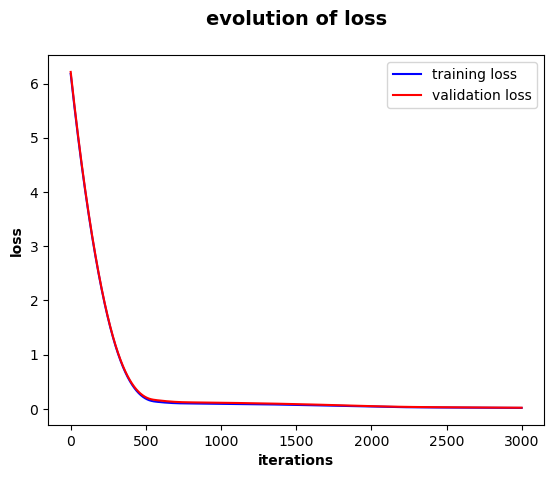

In [23]:
fig, ax = plt.subplots()  
ax.plot(pinn.loss_history, 'b')
ax.plot(pinn.loss_val_history, 'r')
# ax.set_xlim(5, 0)
ax.set_xlabel('iterations', 
               fontweight ='bold')
ax.set_ylabel('loss', 
               fontweight ='bold')
# ax.grid(True)
  
ax.set_title('evolution of loss\n', fontsize = 14, fontweight ='bold')
plt.savefig('loss.png')
plt.legend(['training loss', 'validation loss'])
plt.show()

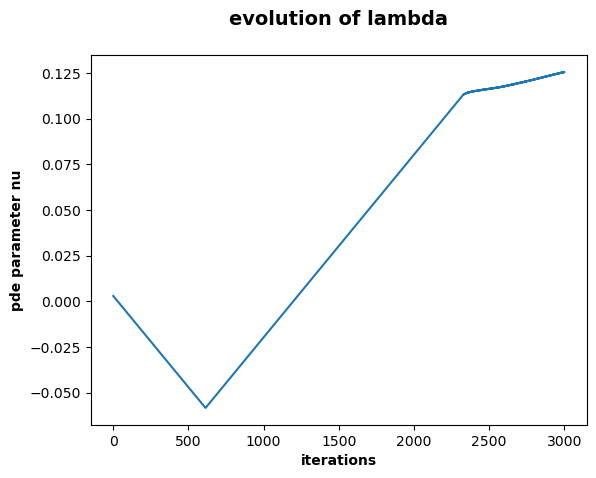

In [24]:
fig, ax = plt.subplots()  
ax.plot(pinn.nu_history)
ax.set_xlabel('iterations', 
               fontweight ='bold')
ax.set_ylabel('pde parameter nu', 
               fontweight ='bold')
# ax.grid(True)
  
ax.set_title('evolution of lambda\n', fontsize = 14, fontweight ='bold')
plt.savefig('nu.png')
plt.show()

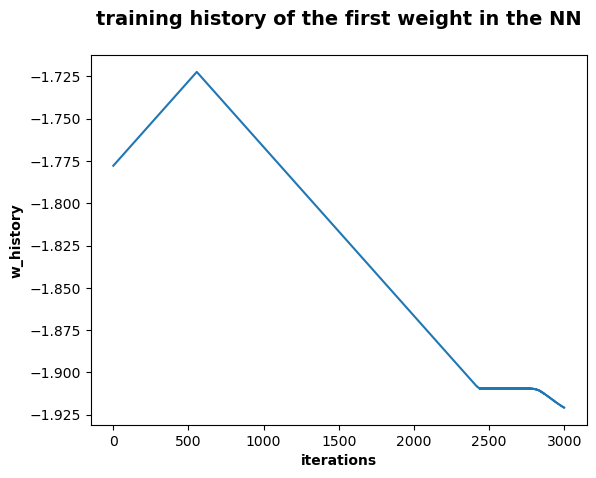

In [25]:
fig, ax = plt.subplots()  
ax.plot(pinn.w_history)
ax.set_xlabel('iterations', 
               fontweight ='bold')
ax.set_ylabel('w_history', 
               fontweight ='bold')
# ax.grid(True)
  
ax.set_title('training history of the first weight in the NN\n', fontsize = 14, fontweight ='bold')
plt.savefig('w0.png')
plt.show()

In [166]:
X_u_test.shape

(25600, 2)

In [167]:
pinn.nu

<tf.Variable 'Variable:0' shape=() dtype=float64, numpy=0.10906229227091135>